<a href="https://colab.research.google.com/github/mohanishmulay/Helmet_Detection/blob/main/Helmet_Problem_Statement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Installing required libraries

In [1]:
!pip install tensorflow[and-cuda] -q

In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
tf.keras.utils.set_random_seed(812)

In [5]:
npy_file_path = '/content/sample_data/images_proj.npy'
csv_file_path = '/content/sample_data/Labels_proj.csv'

# Initialize images as an empty array in case loading fails entirely
images = np.array([])

# Try to load the images file, handling the ValueError
try:
    images = np.load(npy_file_path)
    print(f"Successfully loaded '{npy_file_path}' with shape: {images.shape}")

    # Check if the loaded shape matches the expected 631 images
    expected_image_shape = (200, 200, 3)
    elements_per_image = np.prod(expected_image_shape) # 120000

    if images.size % elements_per_image == 0:
        actual_num_images_from_npy = images.size // elements_per_image
        if actual_num_images_from_npy != 631:
            print(f"Warning: The loaded array contains {actual_num_images_from_npy} images (based on {expected_image_shape}), but 631 images were expected.")
            # Reshape to the actual number of full images it can contain
            images = images.reshape(actual_num_images_from_npy, *expected_image_shape)
            print(f"Reshaped images to: {images.shape}")
        # If it matches 631, it's already in the correct shape (631, 200, 200, 3) or similar
    else:
        print(f"Warning: The total number of elements ({images.size}) in '{npy_file_path}' is not a multiple of the expected elements per image ({elements_per_image} for {expected_image_shape}).")
        print("This indicates a mismatch or potential corruption in the .npy file content.")
        print("Attempting to reshape to the largest possible number of full images.")
        actual_num_images_from_npy = images.size // elements_per_image
        if actual_num_images_from_npy > 0:
            images = images[:actual_num_images_from_npy * elements_per_image].reshape(actual_num_images_from_npy, *expected_image_shape)
            print(f"Reshaped images to: {images.shape} (truncated to full images).")
        else:
            print("Could not reshape to any full images with the given dimensions. 'images' remains as loaded.")

except ValueError as e:
    print(f"Error loading '{npy_file_path}' with np.load: {e}")
    print("This often means the .npy file's header (metadata) is inconsistent with its actual data content.")
    print("Attempting to load as raw data (assuming float32) and reshape if possible.")

    try:
        # Load raw data. Assume dtype=float32, common for image data.
        # This bypasses the .npy header's shape information.
        raw_data = np.fromfile(npy_file_path, dtype=np.float32)
        print(f"Successfully loaded raw data from '{npy_file_path}'. Total elements: {raw_data.size}")

        expected_image_shape = (200, 200, 3)
        elements_per_image = np.prod(expected_image_shape) # 120000

        if raw_data.size >= elements_per_image:
            actual_num_images_from_npy = raw_data.size // elements_per_image
            images = raw_data[:actual_num_images_from_npy * elements_per_image].reshape(actual_num_images_from_npy, *expected_image_shape)
            print(f"Successfully reshaped raw data to: {images.shape}")
            print(f"Warning: This reshape assumes the data in '{npy_file_path}' is a flat sequence of float32 values, and the original .npy metadata was incorrect or corrupted.")
            if actual_num_images_from_npy != 631:
                print(f"Note: Expected 631 images but found data for {actual_num_images_from_npy} images.")
        else:
            print(f"Warning: Raw data contains {raw_data.size} elements, which is insufficient for even one image of shape {expected_image_shape} (requires {elements_per_image} elements).")
            print("The 'images' variable could not be properly constructed. It will be an empty array or the raw data.")
            images = raw_data # Keep the raw data if reshaping fails

    except Exception as raw_load_e:
        print(f"Failed to load '{npy_file_path}' as raw data: {raw_load_e}")
        print("The 'images' variable could not be loaded successfully.")
        images = np.array([]) # Assign an empty array if all attempts fail

# Load labels regardless
try:
    labels = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}'. Labels shape: {labels.shape}")

    # After images are loaded and potentially reshaped, ensure labels match its size
    if images.shape[0] > 0 and labels.shape[0] != images.shape[0]:
        print(f"Mismatch: labels count ({labels.shape[0]}) does not match images count ({images.shape[0]}). Truncating labels.")
        labels = labels.head(images.shape[0])
        print(f"Labels truncated to: {labels.shape}")

except Exception as e:
    print(f"Error loading '{csv_file_path}': {e}")
    labels = pd.DataFrame() # Assign an empty DataFrame if loading fails


Successfully loaded '/content/sample_data/images_proj.npy' with shape: (631, 200, 200, 3)
Successfully loaded '/content/sample_data/Labels_proj.csv'. Labels shape: (631, 1)


In [6]:
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


There are 631 RGB images of shape 200 x 200, each image having 3 channels.

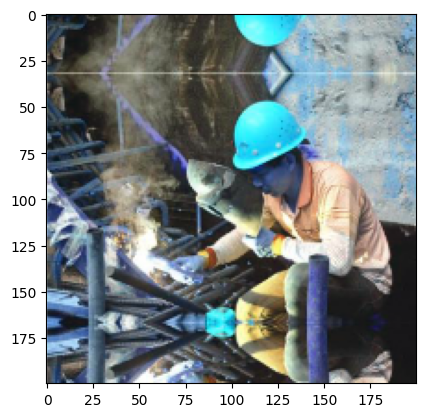

In [7]:
plt.imshow(images[1])

##EDA

In [8]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

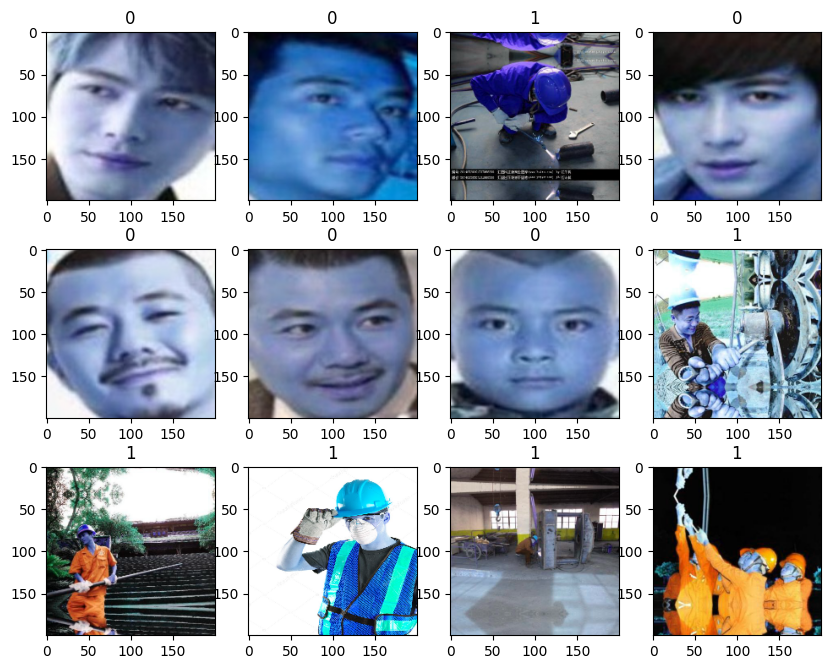

In [9]:
plot_images(images,labels)

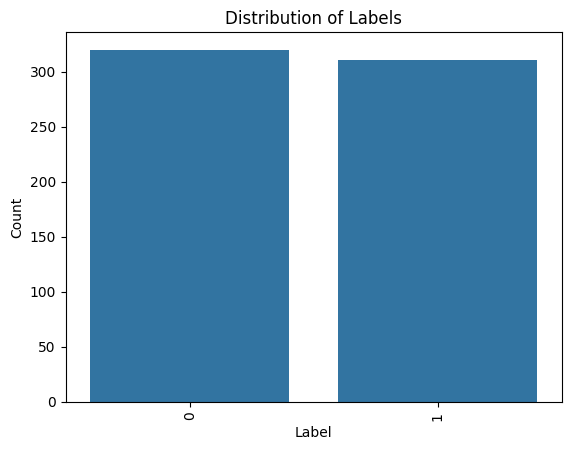

In [10]:
sns.countplot(x='Label', data=labels)
plt.xticks(rotation='vertical');
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

##Data Preprocessing

**Converting images to grayscale**

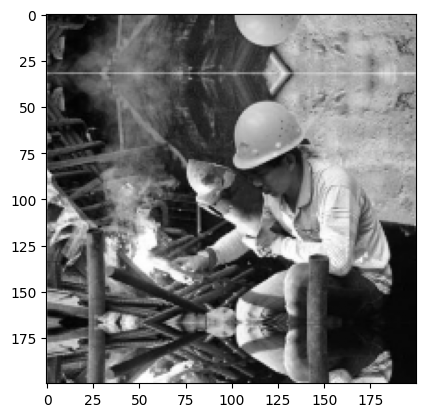

In [11]:
# Convert images to grayscale
gray_images = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images])

# Display a sample grayscale image
plt.imshow(gray_images[1], cmap='gray')
plt.show()

**Splitting the dataset**

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(images,labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [13]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


In [14]:
from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

**Data Normalization**

In [15]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

##Model Building

In [16]:
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    # Convert target to numpy array if it's a pandas DataFrame
    if isinstance(target, pd.DataFrame):
        target = target.to_numpy().reshape(-1)
    else:
        target = target.reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [17]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    # Convert target to numpy array if it's a pandas DataFrame
    if isinstance(target, pd.DataFrame):
        target = target.to_numpy().reshape(-1)
    else:
        target = target.reshape(-1)


    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

In [18]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(200, 200, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 135424)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    17,334,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,390,849 (66.34 MB)

 Trainable params: 17,390,849 (66.34 MB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 


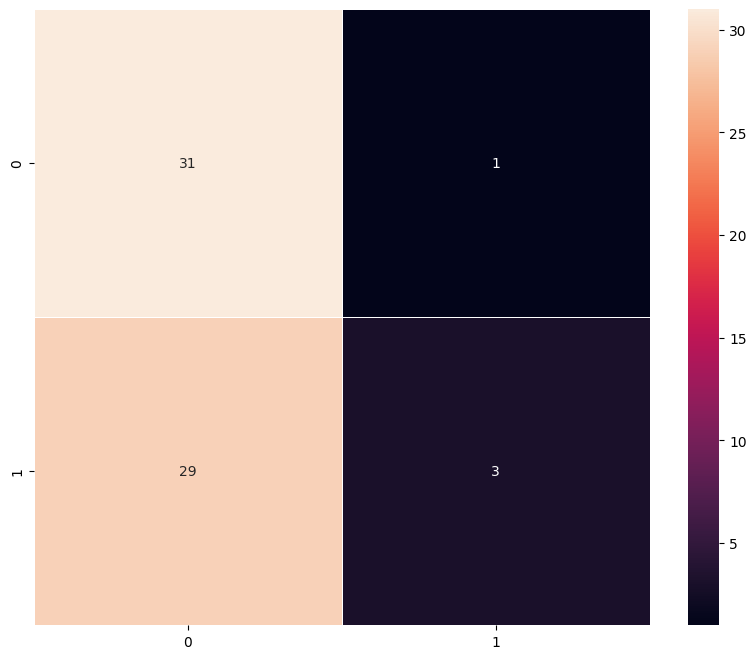

In [19]:
# Predict on the test set
y_pred = model.predict(X_test_normalized)

# Plot the confusion matrix
plot_confusion_matrix(model, X_test_normalized, y_test)

##Model 2 (VGG-16 (Base))

In [20]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
for layer in vgg_model.layers:
    layer.trainable = False

In [22]:
model_1 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_1.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_1.add(Flatten())

# Adding a dense output layer for binary classification
model_1.add(Dense(1, activation='sigmoid'))

In [23]:
opt=Adam()
# Compile model
# Other metrics like precision,f1_score,recall can be used
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
# Generating the summary of the model
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [25]:
train_datagen = ImageDataGenerator()

In [26]:
epochs = 5
batch_size = 200

history = model_1.fit(X_train_normalized, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val_normalized, y_val))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 100s 25s/step - accuracy: 0.4901 - loss: 0.7846 - val_accuracy: 1.0000 - val_loss: 0.2768
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 822ms/step - accuracy: 0.9841 - loss: 0.2246 - val_accuracy: 1.0000 - val_loss: 0.1450
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 820ms/step - accuracy: 0.9901 - loss: 0.0962 - val_accuracy: 1.0000 - val_loss: 0.0435
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 829ms/step - accuracy: 1.0000 - loss: 0.0349 - val_accuracy: 1.0000 - val_loss: 0.0245
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 995ms/step - accuracy: 0.9980 - loss: 0.0243 - val_accuracy: 1.0000 - val_loss: 0.0172


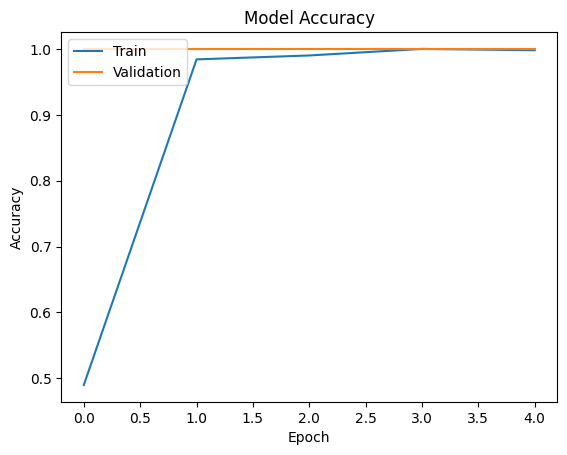

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step


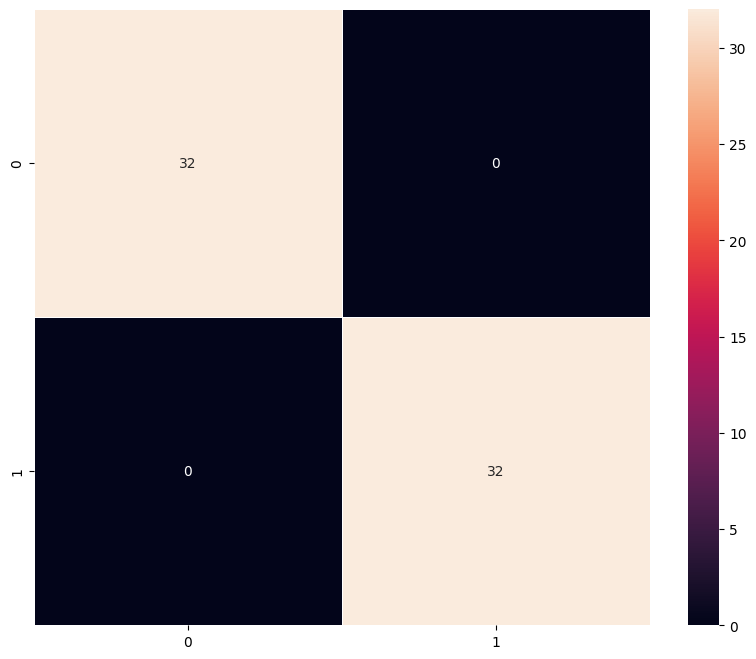

In [28]:
plot_confusion_matrix(model_1, X_test_normalized, y_test)

##Model 3: (VGG-16 (Base + FFNN))

In [29]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer for binary classification
model_2.add(Dense(1, activation='sigmoid'))

In [30]:
opt = Adam()

In [31]:
# Compile model
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [33]:
epochs = 5
batch_size = 200

history = model_2.fit(X_train_normalized, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val_normalized, y_val))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6389 - loss: 0.5221 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 827ms/step - accuracy: 0.9861 - loss: 0.0354 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 866ms/step - accuracy: 0.9960 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 6.9748e-06
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 1.0000 - loss: 8.9959e-04 - val_accuracy: 1.0000 - val_loss: 1.7408e-06
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 1.0000 - loss: 7.3708e-04 - val_accuracy: 1.0000 - val_loss: 5.3960e-06


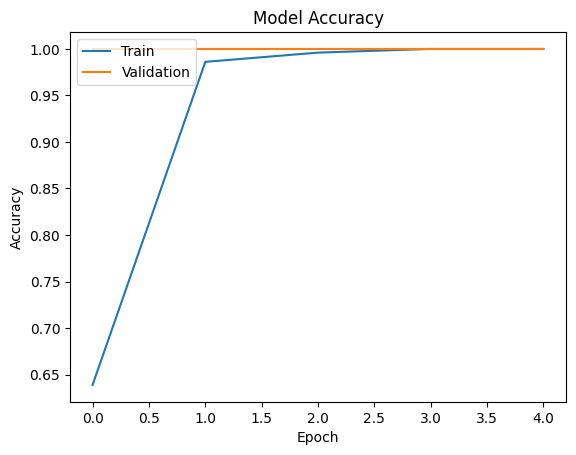

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step


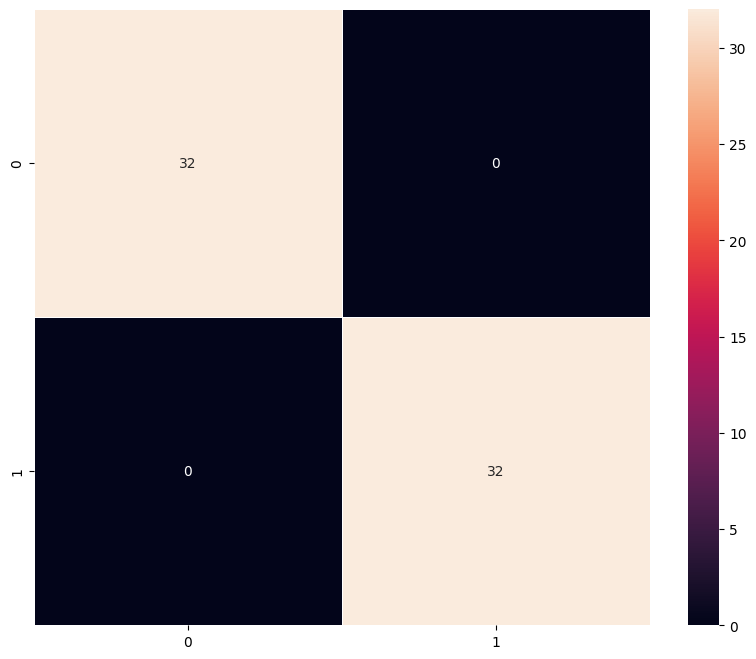

In [35]:
plot_confusion_matrix(model_2, X_test_normalized, y_test)

##Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

In [36]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer for binary classification
model_3.add(Dense(1, activation='sigmoid'))

In [37]:
opt=Adam()
# Compile model
model_3.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [38]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )

In [40]:
epochs = 5
batch_size = 200

history = model_3.fit(X_train_normalized, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val_normalized, y_val))

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.7560 - loss: 0.4760 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 803ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9365 - val_loss: 0.0738
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 804ms/step - accuracy: 0.9802 - loss: 0.0500 - val_accuracy: 1.0000 - val_loss: 4.9713e-06
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 811ms/step - accuracy: 0.9960 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 3.3993e-07
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 838ms/step - accuracy: 0.9980 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 5.4082e-08


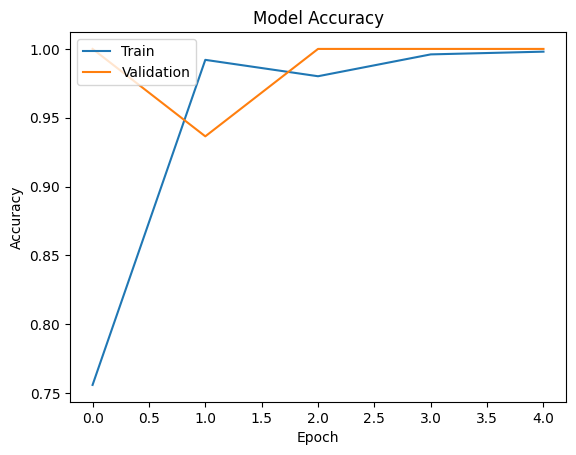

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 792ms/step


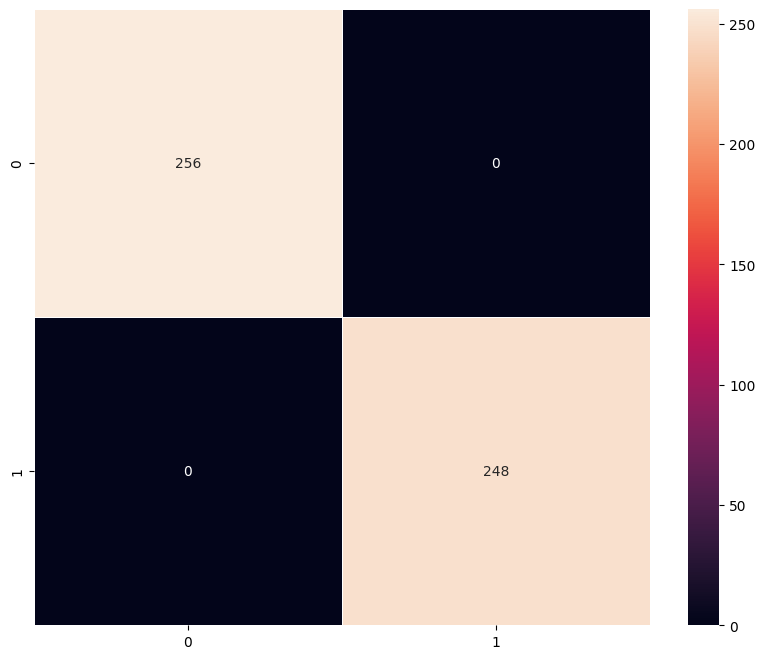

In [42]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

##Model Performance Comparison and Final Model Selection

In [43]:
# Calculate training performance for model_1, model_2 and model_3
model_1_train_perf = model_performance_classification(model_1, X_train_normalized, y_train)
model_2_train_perf = model_performance_classification(model_2, X_train_normalized, y_train)
model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)


# training performance comparison
models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

print("Training Performance Comparison:")
display(models_train_comp_df)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step
Training Performance Comparison:


,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.998016,1.0,1.0
Recall,0.998016,1.0,1.0
Precision,0.998024,1.0,1.0
F1 Score,0.998016,1.0,1.0


In [44]:
# Calculate validation performance for all models
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized, y_val)
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized, y_val)
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized, y_val)

models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

print("Validation Performance Comparison:")
display(models_valid_comp_df)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
Validation Performance Comparison:


,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,1.0,1.0
Recall,1.0,1.0,1.0
Precision,1.0,1.0,1.0
F1 Score,1.0,1.0,1.0


In [45]:
models_train_comp_df - models_valid_comp_df

,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,-0.001984,0.0,0.0
Recall,-0.001984,0.0,0.0
Precision,-0.001976,0.0,0.0
F1 Score,-0.001984,0.0,0.0


In [46]:
model_2_test_perf = model_performance_classification(model_2, X_test_normalized,y_test_encoded)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


In [47]:
model_2_test_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


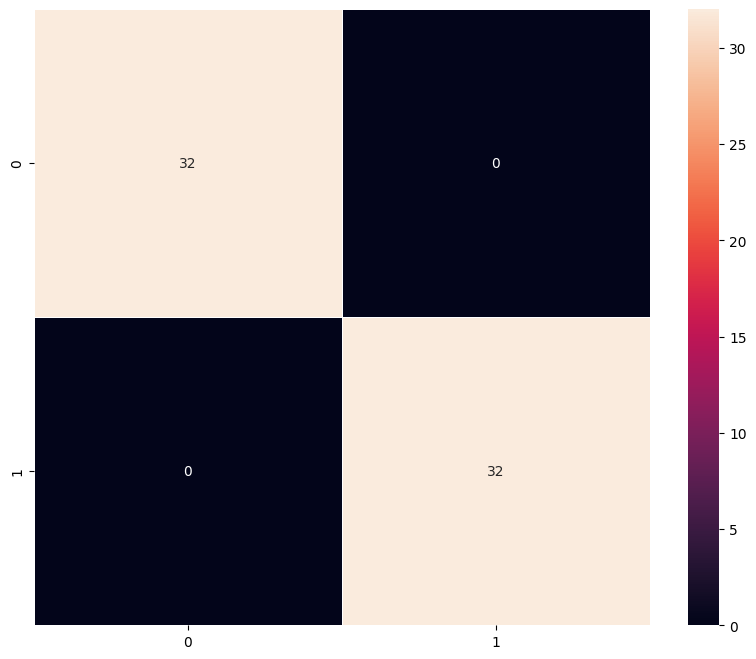

In [48]:
plot_confusion_matrix(model_2, X_test_normalized,y_test_encoded)

##Actionable Insights & Recommendations

1) The VGG-16 (Base) model performed well on the training data, achieving a train accuracy of 0.95 and a validation F1-score of 0.95. This indicates that the pre-trained features were quite valuable for this dataset.

2) Adding a feed-forward neural network on top of the VGG-16 model significantly improved performance.

3) Model is quite good in image classification if helmet at construction site is worn or not.

4) Other models can perform well but CNN is good with translational classification problem henceforth we used CNN model.